In [1]:
import numpy as np 
import matplotlib.pyplot as plt

import matplotlib
matplotlib.rcParams.update({
    "text.usetex": True,
})

import func


In [2]:
c = 2
mu1 = func.Ez(lambda z: z*np.tanh(c*z) )
sig_np = lambda x: np.tanh(c*x) - mu1*x
sig = lambda x: tf.nn.tanh(c*x) - mu1*x

g, dg, l_e, m_e, l_s, m_s = func.sig_related(sig_np)

In [3]:
beta = 1
folder = f'sgd_data_beta_{beta}_new'

d = 200
k = 100
v = func.v_generate(k, beta)
Delta = 0.01

In [4]:
# experimental results, width=kc
errs_kc = []
for iter in [1,2,3,4,5,6,7,8,9]:
    err_kc = np.loadtxt(f'sgd_data_beta_{beta}_kc_width/sgd_err_{iter}.csv', delimiter=',')
    errs_kc.append(err_kc)
errs_kc = np.array(errs_kc)
errs_kc_mean = np.mean(errs_kc, axis=0)
errs_kc_std = np.std(errs_kc, axis=0)


In [5]:
# mmse, theory
a, b, p = 2, 70, 20
r = (b/a)**(1/p) 
alphas = np.array([a*r**i for i in range(p+1)])
mmses = np.array([func.solve(int(alpha*d**2), d, Delta, v, g, m_e)[0] for alpha in alphas])
errs_oneshot = np.array([func.one_shot_BO(int(alpha*d**2), d, Delta, v, g, m_e) for alpha in alphas])


In [6]:
def data_processing(iters, widths, alphas, d=200):
    errs_algo_mean = [] 
    errs_algo_std = []
    errs_match_mean = [] 
    errs_match_std = []

    for alpha in alphas:
        errs_algo = []
        errs_match = []
        for iter in iters:
            n = int(alpha*d**2)
            err_widths = np.loadtxt(f'{folder}/sgd_data_{iter}/sgd_err_n_{n}.csv', delimiter=',')
            err_algo = np.min(err_widths) # err achived by student with optimized width
            err_match = err_widths[0] # err achived by student with matching architecture

            errs_algo.append(err_algo)
            errs_match.append(err_match)

        errs_algo_mean.append(np.mean(errs_algo))
        errs_algo_std.append(np.std(errs_algo))

        errs_match_mean.append(np.mean(errs_match))
        errs_match_std.append(np.std(errs_match))

    return errs_algo_mean, errs_algo_std, errs_match_mean, errs_match_std


In [7]:
alphas_1 = alphas[alphas<10]
alphas_2 = alphas[alphas>10]

iters = [1, 2, 3, 4, 5, 6, 7, 8, 9]
widths = [100, 90, 80, 70, 60, 50, 40, 30, 20, 10]
errs_algo_mean, errs_algo_std, errs_match_mean, errs_match_std = data_processing(iters, widths, alphas_1)

iters_ = [1, 2, 3, 4, 5, 6, 7, 8, 9]
widths_ = [100, 90, 80, 70, 60, 50, 40]
errs_algo_mean_, errs_algo_std_, errs_match_mean_, errs_match_std_ = data_processing(iters_, widths_, alphas_2)

errs_algo_mean += errs_algo_mean_
errs_algo_std += errs_algo_std_
errs_match_mean += errs_match_mean_
errs_match_std += errs_match_std_

errs_algo_mean = np.array(errs_algo_mean)
errs_algo_std = np.array(errs_algo_std)
errs_match_mean = np.array(errs_match_mean)
errs_match_std = np.array(errs_match_std)


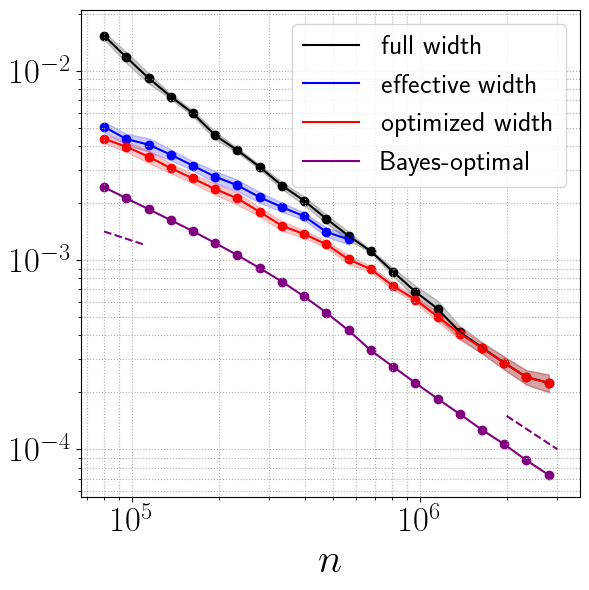

In [ ]:
from matplotlib.ticker import FixedLocator, LogLocator, NullFormatter

size = 25
fig, ax = plt.subplots(figsize=(6, 6), tight_layout=True)

ax.tick_params(axis='both', labelsize=size)

ax.set_xscale('log')
ax.set_xlabel(r'$n$', fontsize=30)

ax.set_yscale('log')
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs='auto'))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.grid(which='major', linestyle=':')
ax.grid(which='minor', linestyle=':')


d = 200
ns = alphas*d**2


color = 'black'
ax.scatter(ns, errs_match_mean, color=color)
ax.plot(ns, errs_match_mean, color=color, label='full width')
ax.fill_between(ns, errs_match_mean - errs_match_std, errs_match_mean + errs_match_std, color=color, alpha=0.2)


color = 'blue'
ax.scatter(ns[:12], errs_kc_mean, color=color)
ax.plot(ns[:12], errs_kc_mean, color=color, label=fr'effective width')
ax.fill_between(ns[:12], errs_kc_mean - errs_kc_std, errs_kc_mean+errs_kc_std, color=color, alpha=0.2)

color = 'red'
ax.scatter(ns, errs_algo_mean, color=color)
ax.plot(ns, errs_algo_mean, color=color, label='optimized width')
ax.fill_between(ns, errs_algo_mean - errs_algo_std, errs_algo_mean + errs_algo_std, color=color, alpha=0.2)


# color = 'green'
# ax.plot(ns, errs_oneshot, color=color, label='one-shot HMC')
# ax.scatter(ns, errs_oneshot, color=color)

color = 'purple'
ax.scatter(ns, mmses, color=color)
ax.plot(ns, mmses, color=color, label='Bayes-optimal')

ns_ = np.array([0.8, 1.1])*1e5
ax.plot(ns_, 0.4*ns_**(1/(2*beta)-1), color=color, linestyle='--')

ns_ = np.array([2, 3])*1e6
ax.plot(ns_, 300*ns_**(-1.0), color=color, linestyle='--')


plt.legend(fontsize=20)

# plt.savefig('figs/scaling_err.pdf')
plt.show()